In [2]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns
%matplotlib inline



In [11]:
# Read the datasets
df_seattle_calendar = pd.read_csv('./data/seattle/calendar.csv')
df_seattle_listings = pd.read_csv('./data/seattle/listings.csv')
# df_seattle_reviews = pd.read_csv('./data/seattle/reviews.csv')


In [6]:
df_seattle_listings.head()

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,review_scores_value,requires_license,license,jurisdiction_names,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,241032,https://www.airbnb.com/rooms/241032,20160104002432,2016-01-04,Stylish Queen Anne Apartment,NaN,Make your self at home in this charming one-be...,Make your self at home in this charming one-be...,none,NaN,...,10.0,f,NaN,WASHINGTON,f,moderate,f,f,2,4.07
1,953595,https://www.airbnb.com/rooms/953595,20160104002432,2016-01-04,Bright & Airy Queen Anne Apartment,Chemically sensitive? We've removed the irrita...,"Beautiful, hypoallergenic apartment in an extr...",Chemically sensitive? We've removed the irrita...,none,"Queen Anne is a wonderful, truly functional vi...",...,10.0,f,NaN,WASHINGTON,f,strict,t,t,6,1.48
2,3308979,https://www.airbnb.com/rooms/3308979,20160104002432,2016-01-04,New Modern House-Amazing water view,New modern house built in 2013. Spectacular s...,"Our house is modern, light and fresh with a wa...",New modern house built in 2013. Spectacular s...,none,Upper Queen Anne is a charming neighborhood fu...,...,10.0,f,NaN,WASHINGTON,f,strict,f,f,2,1.15
3,7421966,https://www.airbnb.com/rooms/7421966,20160104002432,2016-01-04,Queen Anne Chateau,A charming apartment that sits atop Queen Anne...,NaN,A charming apartment that sits atop Queen Anne...,none,NaN,...,NaN,f,NaN,WASHINGTON,f,flexible,f,f,1,NaN
4,278830,https://www.airbnb.com/rooms/278830,20160104002432,2016-01-04,Charming craftsman 3 bdm house,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,none,We are in the beautiful neighborhood of Queen ...,...,9.0,f,NaN,WASHINGTON,f,strict,f,f,1,0.89


In [8]:
df_seattle_listings.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'name', 'summary',
       'space', 'description', 'experiences_offered', 'neighborhood_overview',
       'notes', 'transit', 'thumbnail_url', 'medium_url', 'picture_url',
       'xl_picture_url', 'host_id', 'host_url', 'host_name', 'host_since',
       'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood',
       'host_listings_count', 'host_total_listings_count',
       'host_verifications', 'host_has_profile_pic', 'host_identity_verified',
       'street', 'neighbourhood', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'city', 'state', 'zipcode', 'market',
       'smart_location', 'country_code', 'country', 'latitude', 'longitude',
       'is_location_exact', 'property_type', 'room_type', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'bed_type', 'amenities', '

In [12]:
df_seattle_calendar.head()

,listing_id,date,available,price
0,241032,2016-01-04,t,$85.00
1,241032,2016-01-05,t,$85.00
2,241032,2016-01-06,f,NaN
3,241032,2016-01-07,f,NaN
4,241032,2016-01-08,f,NaN


## How differ the neighbourhoods in respect to accomodation types?


In [14]:
neighbourhood_cleansed = set(df_seattle_listings['neighbourhood_cleansed'])
len(neighbourhood_cleansed)

87

87 neighborhood categories will not result in a very readable overview. So we should try to use a bit more dense grouping.

In [16]:
neighbourhood_group_cleansed = set(df_seattle_listings['neighbourhood_group_cleansed'])
len(neighbourhood_group_cleansed)

17

In [18]:
neighbourhood_group_cleansed

{'Ballard',
 'Beacon Hill',
 'Capitol Hill',
 'Cascade',
 'Central Area',
 'Delridge',
 'Downtown',
 'Interbay',
 'Lake City',
 'Magnolia',
 'Northgate',
 'Other neighborhoods',
 'Queen Anne',
 'Rainier Valley',
 'Seward Park',
 'University District',
 'West Seattle'}

In [33]:
# Counts per property type for 'Ballard' neighbourhood
ballard_count_per_type = df_seattle_listings[df_seattle_listings['neighbourhood_group_cleansed'] == 'Ballard']['property_type'].value_counts()
ballard_count_per_type

House              146
Apartment           60
Townhouse           11
Condominium          3
Camper/RV            2
Bungalow             2
Loft                 2
Bed & Breakfast      2
Cabin                1
Boat                 1
Name: property_type, dtype: int64

In [101]:
ballard_count_per_type.index

Index(['House', 'Apartment', 'Townhouse', 'Condominium', 'Camper/RV',
       'Bungalow', 'Loft', 'Bed & Breakfast', 'Cabin', 'Boat'],
      dtype='object')

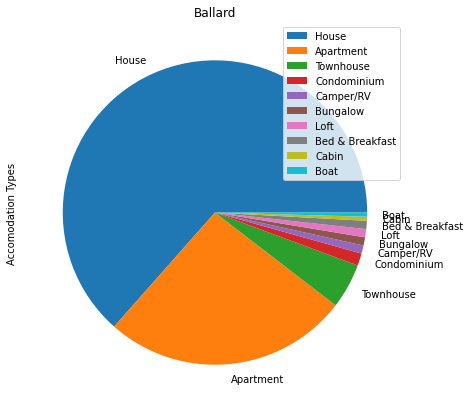

In [45]:
# cake diagramm for 'Ballard'
plot = ballard_count_per_type.plot.pie(title='Ballard', legend=True, ylabel='Accomodation Types', figsize=(7, 7))

In [139]:
# make a set of all accommodation types
acco_types = set(df_seattle_listings['property_type'].dropna(axis=0))
acco_types

{'Apartment',
 'Bed & Breakfast',
 'Boat',
 'Bungalow',
 'Cabin',
 'Camper/RV',
 'Chalet',
 'Condominium',
 'Dorm',
 'House',
 'Loft',
 'Other',
 'Tent',
 'Townhouse',
 'Treehouse',
 'Yurt'}

In [151]:
def plot_accomodation_type_pie(sub_plot, df, neighbourhood_name):
    count_per_type = df[df['neighbourhood_group_cleansed'] == neighbourhood_name]['property_type'].value_counts()
    # add zeros for accomodations not provided at all
    for acco_type in acco_types:
        if acco_type not in count_per_type:
            count_per_type[acco_type] = 0
    count_per_type.sort_index(inplace=True)
    sub_plot.pie(count_per_type)
    sub_plot.set_title(neighbourhood_name, size=25)
    sub_plot.set_ylabel('Accomodation Types', size=15)
    sub_plot.legend(count_per_type.index, loc="upper right", bbox_to_anchor=(-0.1, 1.), fontsize=8)
    
    # sub_plot.set_ylabel='Accomodation Types'
    # title=neighbourhood_name, legend=True, ylabel='Accomodation Types', figsize=(7, 7)

In [ ]:
# before plotting everyting sort list and bring 'Other neighborhoods' to end
neighbourhood_group_cleansed = list(neighbourhood_group_cleansed)
neighbourhood_group_cleansed.sort()
neighbourhood_group_cleansed.remove('Other neighborhoods')
neighbourhood_group_cleansed.append('Other neighborhoods')
neighbourhood_group_cleansed

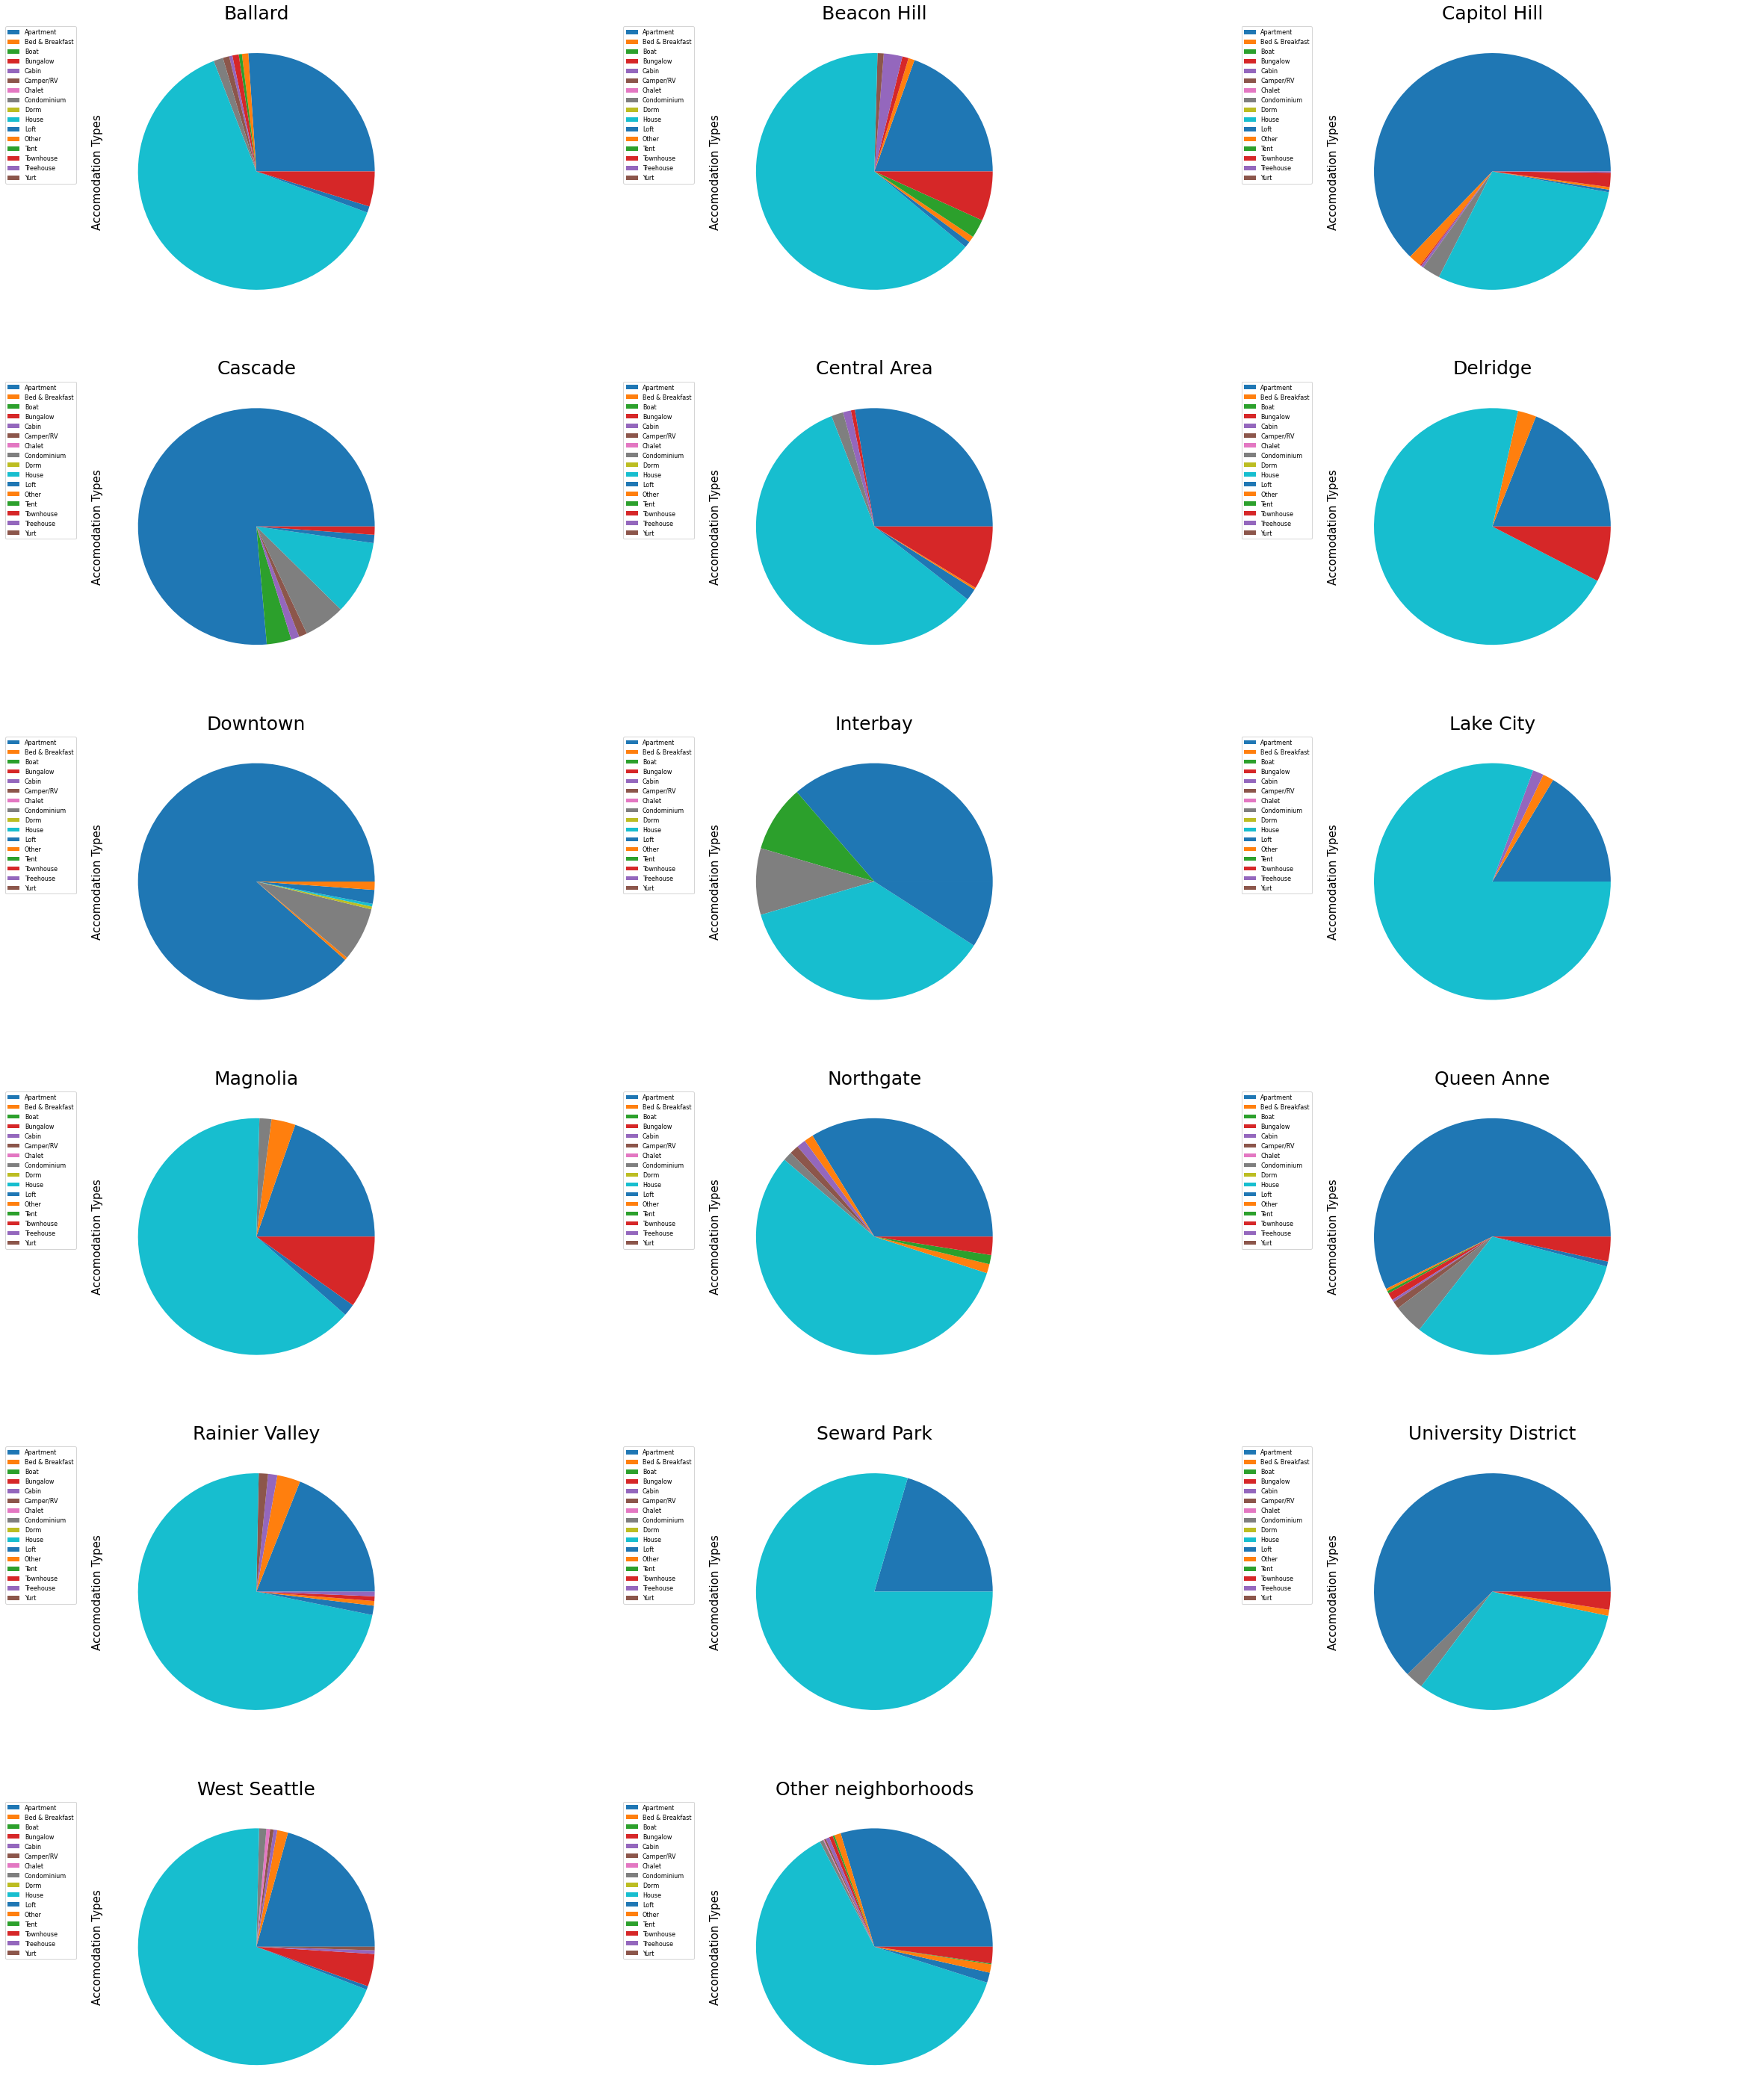

In [152]:
fig, ax = plt.subplots(nrows=6, ncols=3, figsize=(7 * 6,len(neighbourhood_group_cleansed)*3))
# fig, ax = plt.subplots(nrows=len(neighbourhood_group_cleansed), figsize=(7,len(neighbourhood_group_cleansed)*7))
for index, neighbourhood in enumerate(neighbourhood_group_cleansed):
    col = index % 3
    row = int(index / 3)

    plot_accomodation_type_pie(ax[row][col], df_seattle_listings, neighbourhood)
# turn last (unused) subplot off
ax[5,2].set_axis_off()

## In average most expensive and least expensive property type per neighborhood
We will use the daily price without taking additional fees for cleaning aso. into account.

In [171]:
# start again with 'Ballard'
acco_prices = df_seattle_listings[df_seattle_listings['neighbourhood_group_cleansed'] == 'Ballard'][['property_type','price']]

# prices are in string - need to convert them
convert_to_float = lambda col: float(col.split('$')[1])
acco_prices['price'] = acco_prices['price'].apply(convert_to_float)

# df.groupby(['CompanySize']).mean()['JobSatisfaction'].sort_values()
mean_prices_per_group = acco_prices.groupby(['property_type']).mean()['price']
mean_prices_per_group

property_type
Apartment          108.066667
Bed & Breakfast     84.500000
Boat                75.000000
Bungalow            85.000000
Cabin               89.000000
Camper/RV           75.000000
Condominium         88.333333
House              136.589041
Loft                82.000000
Townhouse          106.272727
Name: price, dtype: float64

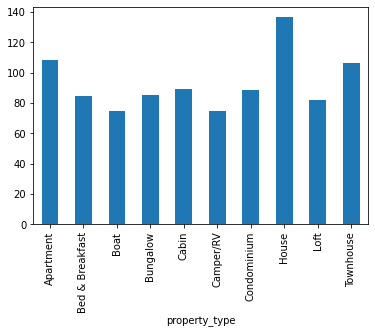

In [174]:
mean_prices_per_group.plot(kind='bar', legend=None);

In [229]:
def plot_medium_price_per_accomodation_type(sub_plot, df, neighbourhood_name):
    acco_prices = df[df['neighbourhood_group_cleansed'] == neighbourhood_name][['property_type','price']]

    # prices are in string - need to convert them
    convert_to_float = lambda col: float(col.split('$')[1].replace(',',''))
    acco_prices['price'] = acco_prices['price'].apply(convert_to_float)

    # df.groupby(['CompanySize']).mean()['JobSatisfaction'].sort_values()
    mean_prices_per_group = acco_prices.groupby(['property_type']).mean()['price'].sort_values(ascending=True)
    mean_prices_per_group.plot(kind='bar', legend=None, ax=sub_plot, fontsize=13)
    sub_plot.set_title(neighbourhood_name, size=25)
    sub_plot.set_ylabel('Accomodation Types', size=15)
    sub_plot.set_ylabel('Average Price per Day', size=15)


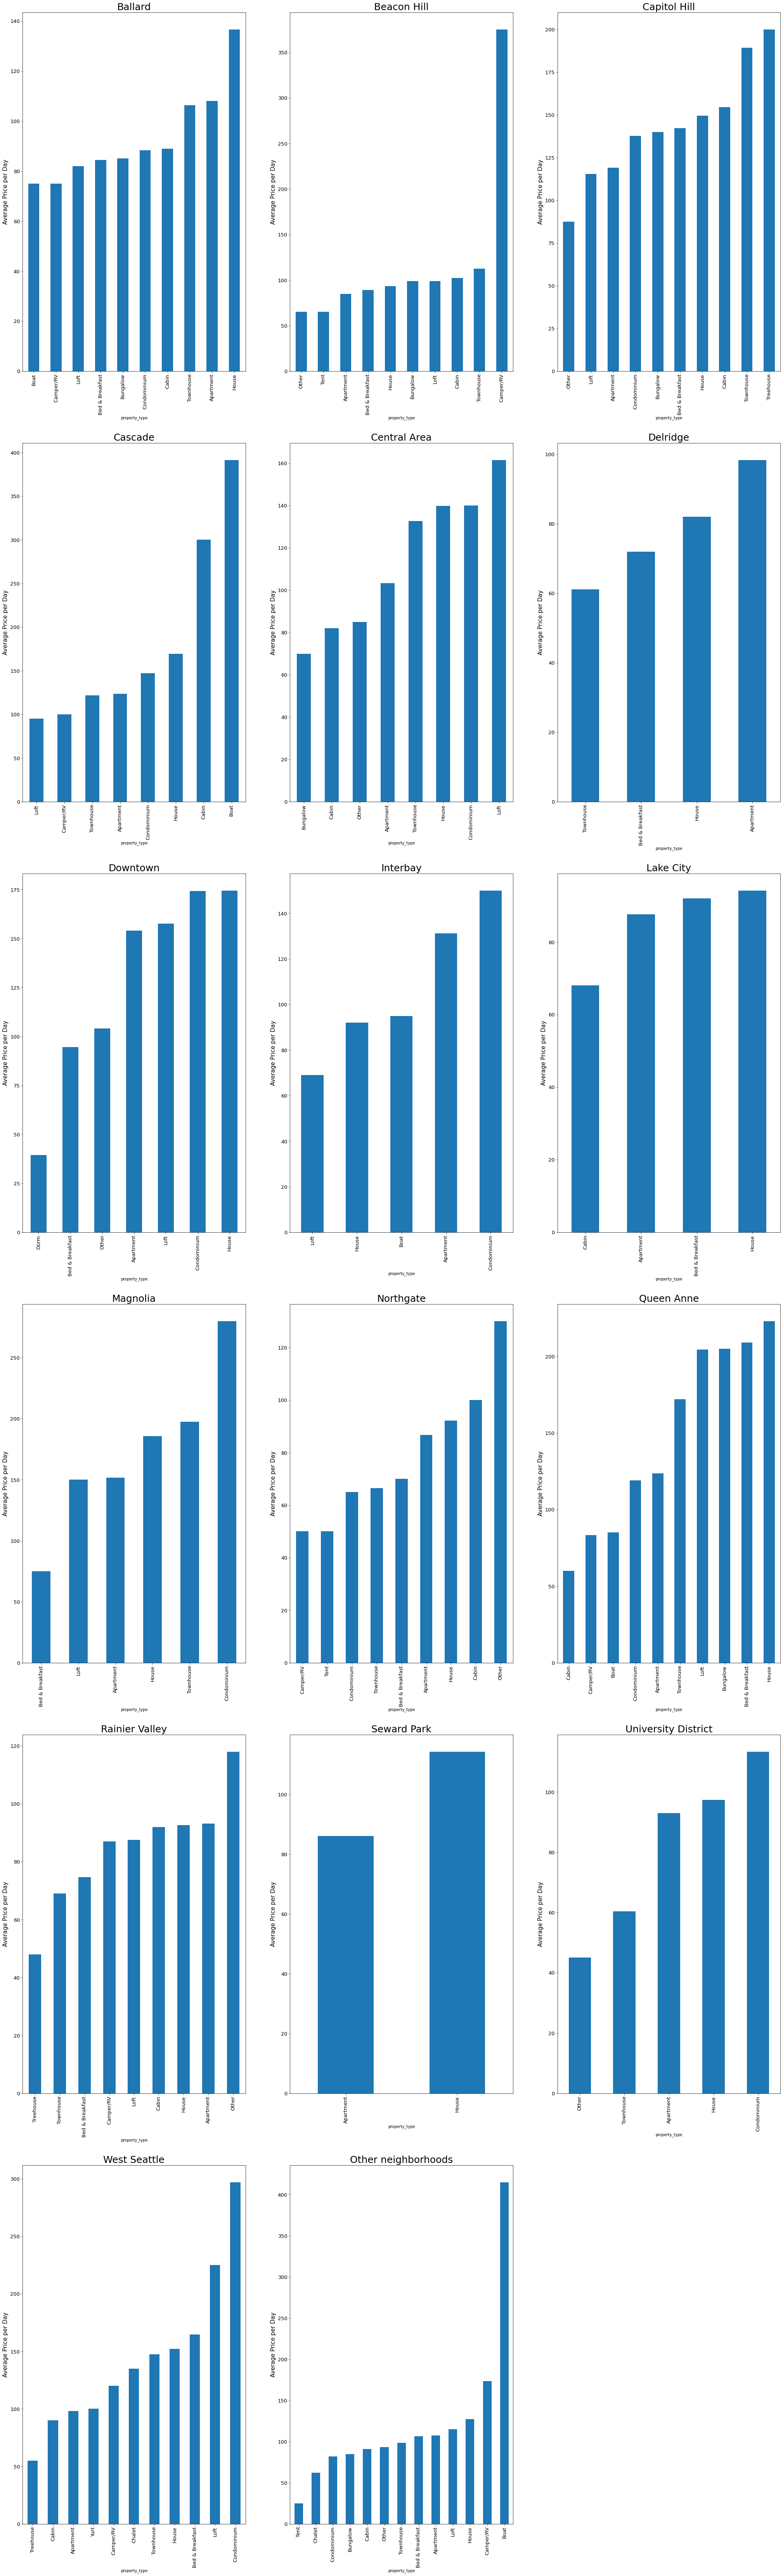

In [232]:
fig, ax = plt.subplots(nrows=6, ncols=3, figsize=(7 * 5,len(neighbourhood_group_cleansed)* 7))
# fig, ax = plt.subplots(nrows=len(neighbourhood_group_cleansed), figsize=(7,len(neighbourhood_group_cleansed)*7))
for index, neighbourhood in enumerate(neighbourhood_group_cleansed):
    col = index % 3
    row = int(index / 3)

    plot_medium_price_per_accomodation_type(ax[row][col], df_seattle_listings, neighbourhood)
# turn last (unused) subplot off
ax[5,2].set_axis_off()